# Hotel Booking - Logistic Regression Pipeline

Notebook nay trien khai day du pipeline cho thuat toan Logistic Regression.

## Phuong Phap Tuning Va Xu Ly Mat Can Bang Lop

> Cell nay duoc them de tien tham khao cho bao cao. Giai thich tai sao notebook LR dung phuong phap tuning + xu ly imbalance KHAC voi cac notebook SVM/RF/NN, va tai sao cac khac biet do hop ly chu khong phai lam au.

### 1. Xu ly mat can bang lop

Dataset co target imbalance ~37% canceled / 63% not canceled. Notebook dung **`class_weight='balanced'`** truyen vao constructor `LogisticRegression(class_weight='balanced')`.

Sklearn tu dong tinh weight theo cong thuc:

```
weight_class = n_samples / (n_classes * count_class)
```

Voi imbalance 37/63, weight cua class "canceled" cao hon class "not canceled", giup loss function phat model nhieu hon khi du doan sai class thieu so. **Day la API chuan cua sklearn cho mo hinh tuyen tinh; trung cach voi SVM va Random Forest** (cung dung `class_weight='balanced'`). Khac MLPClassifier (khong ho tro `class_weight`, phai dung `sample_weight` — tuong duong ve mat toan hoc).

### 2. Hyperparameter tuning

KHAC voi cac notebook khac, notebook nay **KHONG dung GridSearchCV/RandomizedSearchCV** cho cac hyperparam `C` hay `penalty`. Ly do:

1. **Search space hyperparam cua LR rat nho** — chu yeu chi co `C` va `penalty`. Thu `C ∈ [0.01, 0.1, 1, 10]` thuong cho ket qua chenh lech rat it tren bai toan tabular.
2. **Don bay cai thien chinh cua LR la encoding va feature selection**, khong phai hyperparam. Vi vay notebook tap trung thu:
   - **Target encoding** + **Frequency encoding** cho cot cardinality cao (`country` 177 gia tri, `agent` >10000 gia tri) thay vi one-hot.
   - **L1 feature selection** voi `LogisticRegression(penalty='l1', C=0.05)` lam selector, sau do refit LR tren feature da chon.
3. **Ket qua thuc nghiem**: cac thu nghiem nang cao khong vuot duoc baseline `fe_outlier_class_weight_balanced` — chung to LR + one-hot + class_weight + feature engineering co ban da khai thac het tin hieu tuyen tinh trong du lieu.

### 3. So sanh voi cac thuat toan khac

| Thuat toan | Tuning method | Ly do |
|---|---|---|
| **Logistic Regression** (notebook nay) | Encoding + L1 feature selection | Don bay cai thien chinh khong nam o hyperparam |
| SVM (LinearSVC) | GridSearchCV(C ∈ [0.1, 1, 3]) | Search space chi co C, grid 3 gia tri du |
| Random Forest | RandomizedSearchCV(n_iter=8) | Search space lon (108 cau hinh), random tiet kiem thoi gian |
| Neural Network | Manual ParameterGrid (6 configs) | Training MLP cham, CV full ton hang gio |

Khi viet bao cao, nen ghi ro rang cac cach tuning duoc chon **phu hop voi dac tinh tung thuat toan**, khong phai mo hinh nao bi thiet thoi.

## Khoi Tao Thu Vien Va Duong Dan Luu Artifact

Nap thu vien, dinh nghia duong dan du lieu va thu muc luu model/ket qua.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import joblib

sns.set_theme(style='whitegrid', palette='Set2')

DATA_PATH = Path('hotel_bookings.csv')
ARTIFACT_DIR = Path('model/logistic_regression')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


## Nap Du Lieu Va Kiem Tra Ban Dau

Doc dataset va xem nhanh kich thuoc cung mau du lieu.

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape ban dau:', df.shape)
df.head()

Shape ban dau: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Data Cleaning Va Xu Ly Gia Tri Thieu

Xu ly duplicate, missing values, bo cot thieu qua cao va loai bo cot leakage.

In [3]:
# 1) Xoa duplicate
dup_count = df.duplicated().sum()
print('So duplicate truoc khi xoa:', dup_count)
df = df.drop_duplicates().reset_index(drop=True)
print('Shape sau khi xoa duplicate:', df.shape)

# 2) Bo cot company vi thieu qua cao (~94%)
if 'company' in df.columns:
    df = df.drop(columns=['company'])

# 3) Xu ly missing
# agent la ma ID -> coi missing la 1 nhom rieng
df['agent'] = df['agent'].fillna('Unknown').astype(str)

# country la category -> Unknown
df['country'] = df['country'].fillna('Unknown')

# children la numeric, thieu rat it -> median
df['children'] = df['children'].fillna(df['children'].median())

# 4) Bo cot leakage (chua thong tin sau ket qua dat phong)
leakage_cols = ['reservation_status', 'reservation_status_date']
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

print('Missing sau xu ly:')
print(df.isna().sum()[df.isna().sum() > 0])
print('So cot hien tai:', len(df.columns))

So duplicate truoc khi xoa: 31994
Shape sau khi xoa duplicate: (87396, 32)
Missing sau xu ly:
Series([], dtype: int64)
So cot hien tai: 29


## EDA Nhanh Cho Target Va Outlier

Kiem tra phan bo target va quan sat outlier co ban truoc khi train.

Phan bo target:
is_canceled
0    63371
1    24025
Name: count, dtype: int64
is_canceled
0    72.51
1    27.49
Name: count, dtype: float64


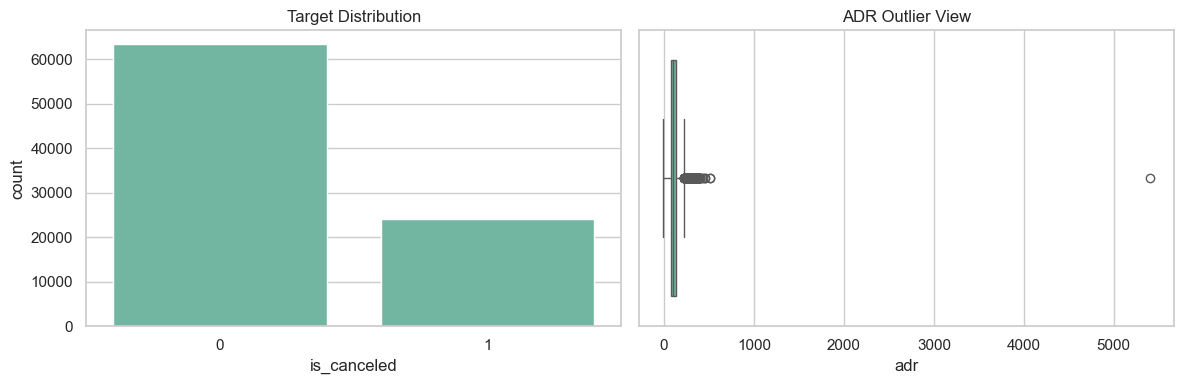

In [4]:
target_dist = df['is_canceled'].value_counts()
print('Phan bo target:')
print(target_dist)
print((target_dist / len(df) * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='is_canceled', ax=axes[0])
axes[0].set_title('Target Distribution')

sns.boxplot(data=df, x='adr', ax=axes[1])
axes[1].set_title('ADR Outlier View')
plt.tight_layout()
plt.show()

## Chia Tap Train/Test

Tach du lieu train-test theo ti le va dung stratify de giu phan bo target.

In [5]:
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

Train shape: (69916, 28)
Test shape : (17480, 28)


## Xay Dung Preprocessing Pipeline

Thiet lap imputation, encoding va scaling bang ColumnTransformer.

In [6]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print('Numeric cols:', len(num_cols))
print('Categorical cols:', len(cat_cols))

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

Numeric cols: 17
Categorical cols: 11


## Train Baseline Logistic Regression



In [7]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000, random_state=42, n_jobs=None))
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Danh Gia Baseline Tren Test Set

Tinh Accuracy, Precision, Recall, F1 va ROC-AUC cho Logistic Regression baseline.

In [8]:
def evaluate_model(model, X_data, y_true, label):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]
    return {
        'model': label,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

baseline_metrics = evaluate_model(baseline_model, X_test, y_test, 'logistic_baseline')
baseline_eval_df = pd.DataFrame([baseline_metrics])
baseline_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,logistic_baseline,0.806407,0.690841,0.535276,0.603189,0.864547


## Danh Gia Mo Hinh Sau Cai Tien Class Weight

Train va danh gia Logistic Regression voi `class_weight='balanced'` de xu ly mat can bang lop.

In [9]:
balanced_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42,
        n_jobs=None
    ))
])

balanced_model.fit(X_train, y_train)
balanced_metrics = evaluate_model(balanced_model, X_test, y_test, 'logistic_class_weight_balanced')
balanced_eval_df = pd.DataFrame([balanced_metrics])
balanced_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,logistic_class_weight_balanced,0.772998,0.558985,0.82539,0.666555,0.865528


## Bang So Sanh Baseline Va Mo Hinh Sau Cai Tien

Tong hop evaluation cua baseline va mo hinh sau cai tien, chon mo hinh tot nhat va luu artifact.

In [10]:
comparison_df = pd.DataFrame([baseline_metrics, balanced_metrics])
comparison_df = comparison_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
comparison_df = comparison_df.sort_values(by=['f1', 'roc_auc'], ascending=False).reset_index(drop=True)
comparison_df

best_name = comparison_df.loc[0, 'model']
best_model = baseline_model if best_name == 'logistic_baseline' else balanced_model

# Luu bang so sanh evaluation
results_path = ARTIFACT_DIR / 'logistic_regression_results.csv'
comparison_df.to_csv(results_path, index=False)

# Luu rieng tung bang evaluation de bao cao de doc hon
baseline_eval_df.to_csv(ARTIFACT_DIR / 'logistic_regression_baseline_evaluation.csv', index=False)
balanced_eval_df.to_csv(ARTIFACT_DIR / 'logistic_regression_class_weight_evaluation.csv', index=False)

# Luu model tot nhat
model_path = ARTIFACT_DIR / 'logistic_regression_best.joblib'
joblib.dump(best_model, model_path)

# Luu metadata
metadata = {
    'algorithm': 'LogisticRegression',
    'best_variant': best_name,
    'selection_metric': 'f1_then_roc_auc',
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'features_used': list(X.columns),
    'dropped_columns': ['company', 'reservation_status', 'reservation_status_date'],
    'missing_handling': {
        'agent': 'fill Unknown',
        'country': 'fill Unknown',
        'children': 'fill median'
    }
}
metadata_path = ARTIFACT_DIR / 'logistic_regression_metadata.json'
metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')

print('Saved:', results_path)
print('Saved:', ARTIFACT_DIR / 'logistic_regression_baseline_evaluation.csv')
print('Saved:', ARTIFACT_DIR / 'logistic_regression_class_weight_evaluation.csv')
print('Saved:', model_path)
print('Saved:', metadata_path)


Saved: model\logistic_regression\logistic_regression_results.csv
Saved: model\logistic_regression\logistic_regression_baseline_evaluation.csv
Saved: model\logistic_regression\logistic_regression_class_weight_evaluation.csv
Saved: model\logistic_regression\logistic_regression_best.joblib
Saved: model\logistic_regression\logistic_regression_metadata.json


## Final Evaluation (Confusion Matrix, ROC)

Danh gia cuoi bang confusion matrix va ROC curve tren tap test.

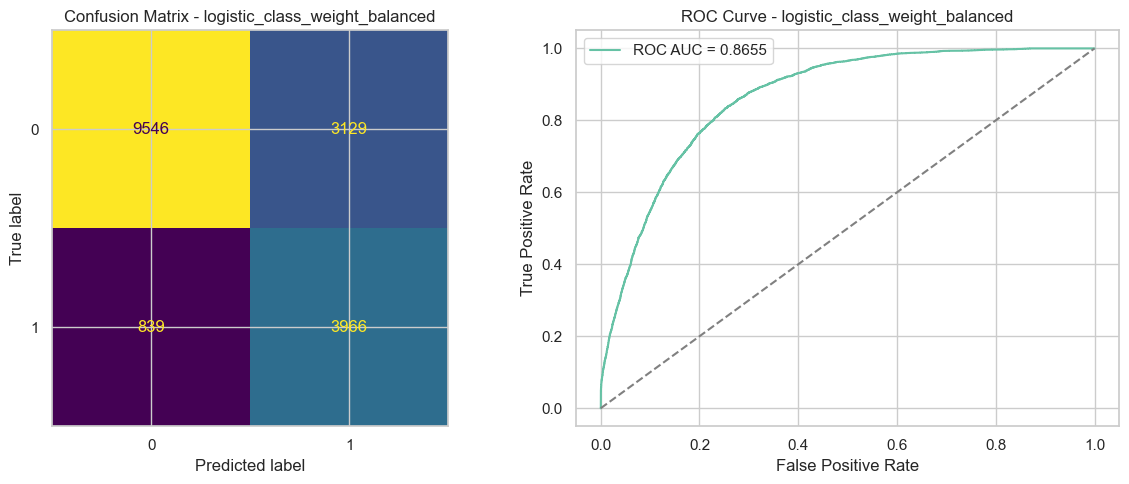

In [11]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix - {best_name}')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_test, y_proba):.4f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - {best_name}')
axes[1].legend()

plt.tight_layout()
plt.show()

## Ket Luan Buoc Logistic Regression

Tong ket ket qua cua Logistic Regression va dinh huong cho buoc tiep theo.

In [12]:
print('Ket luan buoc 1: Da hoan tat Logistic Regression theo pipeline, bao gom cleaning, baseline, xu ly imbalance va luu artifact.')
print('Buoc tiep theo: Feature Engineering + model nang cao (Random Forest / XGBoost / LightGBM).')

Ket luan buoc 1: Da hoan tat Logistic Regression theo pipeline, bao gom cleaning, baseline, xu ly imbalance va luu artifact.
Buoc tiep theo: Feature Engineering + model nang cao (Random Forest / XGBoost / LightGBM).


## Kiem Tra Overfitting Bang Train/Test Metrics

So sanh performance tren train set va test set. Neu train cao hon test qua nhieu, mo hinh co dau hieu overfitting.

In [13]:
def evaluate_train_test_gap(model, X_train, y_train, X_test, y_test, label):
    train_metrics = evaluate_model(model, X_train, y_train, f'{label}_train')
    test_metrics = evaluate_model(model, X_test, y_test, f'{label}_test')
    train_metrics['dataset'] = 'train'
    test_metrics['dataset'] = 'test'
    train_metrics['model_group'] = label
    test_metrics['model_group'] = label
    return train_metrics, test_metrics

rows = []
for model_obj, label in [
    (baseline_model, 'logistic_baseline'),
    (balanced_model, 'logistic_class_weight_balanced')
]:
    rows.extend(evaluate_train_test_gap(model_obj, X_train, y_train, X_test, y_test, label))

overfit_df = pd.DataFrame(rows)
overfit_df = overfit_df[['model_group', 'dataset', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

gap_df = (
    overfit_df
    .pivot(index='model_group', columns='dataset', values=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
)

gap_summary = pd.DataFrame(index=gap_df.index)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    gap_summary[f'{metric}_gap_train_minus_test'] = gap_df[(metric, 'train')] - gap_df[(metric, 'test')]

overfit_df.to_csv(ARTIFACT_DIR / 'logistic_regression_overfitting_check.csv', index=False)
gap_summary.reset_index().to_csv(ARTIFACT_DIR / 'logistic_regression_overfitting_gap.csv', index=False)

display(overfit_df.round(4))
display(gap_summary.round(4))


,model_group,dataset,accuracy,precision,recall,f1,roc_auc
0,logistic_baseline,train,0.8082,0.6936,0.5415,0.6082,0.8681
1,logistic_baseline,test,0.8064,0.6908,0.5353,0.6032,0.8645
2,logistic_class_weight_balanced,train,0.7761,0.5628,0.8313,0.6712,0.8686
3,logistic_class_weight_balanced,test,0.7730,0.5590,0.8254,0.6666,0.8655


,accuracy_gap_train_minus_test,precision_gap_train_minus_test,recall_gap_train_minus_test,f1_gap_train_minus_test,roc_auc_gap_train_minus_test
model_group,,,,,
logistic_baseline,0.0018,0.0028,0.0062,0.0050,0.0036
logistic_class_weight_balanced,0.0031,0.0038,0.0059,0.0046,0.0031


## Thu Nghiem Feature Engineering Va Xu Ly Outlier

Tao mot nhanh thu nghiem rieng dua tren du lieu da cleaning. Cell nay khong thay doi cac model baseline/class_weight da train o tren.

In [14]:
# Tao ban sao de thu nghiem, khong anh huong df goc/model cu
fe_df = df.copy()

month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

# Feature engineering
fe_df['total_nights'] = fe_df['stays_in_weekend_nights'] + fe_df['stays_in_week_nights']
fe_df['total_guests'] = fe_df['adults'] + fe_df['children'] + fe_df['babies']
fe_df['has_children'] = (fe_df['children'] > 0).astype(int)
fe_df['is_family'] = ((fe_df['children'] + fe_df['babies']) > 0).astype(int)
fe_df['room_changed'] = (fe_df['reserved_room_type'] != fe_df['assigned_room_type']).astype(int)
fe_df['has_agent'] = (fe_df['agent'] != 'Unknown').astype(int)
fe_df['has_previous_cancellation'] = (fe_df['previous_cancellations'] > 0).astype(int)
fe_df['arrival_month_number'] = fe_df['arrival_date_month'].map(month_map)

# Outlier handling bang clipping percentile 1%-99%
outlier_cols = ['adr', 'adults', 'lead_time', 'days_in_waiting_list']
clip_bounds = {}
for col in outlier_cols:
    lower = fe_df[col].quantile(0.01)
    upper = fe_df[col].quantile(0.99)
    clip_bounds[col] = {'lower': float(lower), 'upper': float(upper)}
    fe_df[col] = fe_df[col].clip(lower=lower, upper=upper)

print('Shape sau feature engineering:', fe_df.shape)
print('Feature moi:')
print(['total_nights', 'total_guests', 'has_children', 'is_family', 'room_changed', 'has_agent', 'has_previous_cancellation', 'arrival_month_number'])
print('Clip bounds:')
clip_bounds


Shape sau feature engineering: (87396, 37)
Feature moi:
['total_nights', 'total_guests', 'has_children', 'is_family', 'room_changed', 'has_agent', 'has_previous_cancellation', 'arrival_month_number']
Clip bounds:


{'adr': {'lower': 0.0, 'upper': 261.40500000000026},
 'adults': {'lower': 1.0, 'upper': 3.0},
 'lead_time': {'lower': 0.0, 'upper': 347.0},
 'days_in_waiting_list': {'lower': 0.0, 'upper': 0.0}}

## Train/Test Split Cho Du Lieu Cai Tien

Chia lai train/test tren dataset da co feature engineering va outlier clipping, van dung random_state va stratify nhu nhanh goc.

In [15]:
X_fe = fe_df.drop(columns=['is_canceled'])
y_fe = fe_df['is_canceled']

X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

num_cols_fe = X_fe_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_fe = X_fe_train.select_dtypes(include=['object']).columns.tolist()

print('Train shape:', X_fe_train.shape)
print('Test shape :', X_fe_test.shape)
print('Numeric cols:', len(num_cols_fe))
print('Categorical cols:', len(cat_cols_fe))


Train shape: (69916, 36)
Test shape : (17480, 36)
Numeric cols: 25
Categorical cols: 11


## Preprocessing Va Train Logistic Regression Sau Cai Tien

Tao preprocessing rieng cho dataset da cai tien, sau do train Logistic Regression voi class_weight='balanced'.

In [16]:
preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_fe),
        ('cat', categorical_transformer, cat_cols_fe)
    ]
)

fe_balanced_model = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42,
        n_jobs=None
    ))
])

fe_balanced_model.fit(X_fe_train, y_fe_train)
fe_balanced_metrics = evaluate_model(
    fe_balanced_model,
    X_fe_test,
    y_fe_test,
    'logistic_fe_outlier_class_weight_balanced'
)

fe_eval_df = pd.DataFrame([fe_balanced_metrics])
fe_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,logistic_fe_outlier_class_weight_balanced,0.778375,0.565536,0.836004,0.674672,0.87173


## So Sanh Ket Qua Truoc Va Sau Feature Engineering

So sanh baseline, class_weight va phien ban cai tien moi. Ket qua duoc luu rieng de khong ghi de cac bang cu.

In [17]:
improvement_comparison_df = pd.concat(
    [comparison_df, fe_eval_df],
    ignore_index=True
)[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

improvement_comparison_df = improvement_comparison_df.sort_values(
    by=['f1', 'roc_auc'], ascending=False
).reset_index(drop=True)

improvement_results_path = ARTIFACT_DIR / 'logistic_regression_feature_engineering_outlier_results.csv'
improvement_model_path = ARTIFACT_DIR / 'logistic_regression_feature_engineering_outlier.joblib'

improvement_comparison_df.to_csv(improvement_results_path, index=False)
joblib.dump(fe_balanced_model, improvement_model_path)

print('Saved:', improvement_results_path)
print('Saved:', improvement_model_path)
improvement_comparison_df


Saved: model\logistic_regression\logistic_regression_feature_engineering_outlier_results.csv
Saved: model\logistic_regression\logistic_regression_feature_engineering_outlier.joblib


,model,accuracy,precision,recall,f1,roc_auc
0,logistic_fe_outlier_class_weight_balanced,0.778375,0.565536,0.836004,0.674672,0.871730
1,logistic_class_weight_balanced,0.772998,0.558985,0.825390,0.666555,0.865528
2,logistic_baseline,0.806407,0.690841,0.535276,0.603189,0.864547


## Kiem Tra Overfitting Cho Phien Ban Cai Tien

Danh gia train/test metrics cua phien ban feature engineering + outlier handling de xem co overfitting hay khong.

In [18]:
fe_overfit_rows = list(evaluate_train_test_gap(
    fe_balanced_model,
    X_fe_train,
    y_fe_train,
    X_fe_test,
    y_fe_test,
    'logistic_fe_outlier_class_weight_balanced'
))

fe_overfit_df = pd.DataFrame(fe_overfit_rows)
fe_overfit_df = fe_overfit_df[['model_group', 'dataset', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

fe_gap_df = fe_overfit_df.pivot(index='model_group', columns='dataset', values=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
fe_gap_summary = pd.DataFrame(index=fe_gap_df.index)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    fe_gap_summary[f'{metric}_gap_train_minus_test'] = fe_gap_df[(metric, 'train')] - fe_gap_df[(metric, 'test')]

fe_overfit_df.to_csv(ARTIFACT_DIR / 'logistic_regression_fe_outlier_overfitting_check.csv', index=False)
fe_gap_summary.reset_index().to_csv(ARTIFACT_DIR / 'logistic_regression_fe_outlier_overfitting_gap.csv', index=False)

display(fe_overfit_df.round(4))
display(fe_gap_summary.round(4))


,model_group,dataset,accuracy,precision,recall,f1,roc_auc
0,logistic_fe_outlier_class_weight_balanced,train,0.7807,0.5686,0.838,0.6775,0.8740
1,logistic_fe_outlier_class_weight_balanced,test,0.7784,0.5655,0.836,0.6747,0.8717


,accuracy_gap_train_minus_test,precision_gap_train_minus_test,recall_gap_train_minus_test,f1_gap_train_minus_test,roc_auc_gap_train_minus_test
model_group,,,,,
logistic_fe_outlier_class_weight_balanced,0.0023,0.0031,0.002,0.0029,0.0023


## Thu Nghiem Encoding Tot Hon Va Loai Feature Yeu

Thu target encoding va frequency encoding cho `country`, `agent`, sau do thu loai feature yeu bang L1-based feature selection. Nhanh nay khong thay doi cac model cu.

In [19]:
from sklearn.feature_selection import SelectFromModel

# Dung lai dataset da feature engineering + outlier neu da co.
# Neu chay rieng cell nay, tao lai nhanh FE tu df da cleaning.
if 'fe_df' not in globals():
    fe_df = df.copy()
    month_map = {
        'January': 1, 'February': 2, 'March': 3, 'April': 4,
        'May': 5, 'June': 6, 'July': 7, 'August': 8,
        'September': 9, 'October': 10, 'November': 11, 'December': 12
    }
    fe_df['total_nights'] = fe_df['stays_in_weekend_nights'] + fe_df['stays_in_week_nights']
    fe_df['total_guests'] = fe_df['adults'] + fe_df['children'] + fe_df['babies']
    fe_df['has_children'] = (fe_df['children'] > 0).astype(int)
    fe_df['is_family'] = ((fe_df['children'] + fe_df['babies']) > 0).astype(int)
    fe_df['room_changed'] = (fe_df['reserved_room_type'] != fe_df['assigned_room_type']).astype(int)
    fe_df['has_agent'] = (fe_df['agent'] != 'Unknown').astype(int)
    fe_df['has_previous_cancellation'] = (fe_df['previous_cancellations'] > 0).astype(int)
    fe_df['arrival_month_number'] = fe_df['arrival_date_month'].map(month_map)
    for col in ['adr', 'adults', 'lead_time', 'days_in_waiting_list']:
        fe_df[col] = fe_df[col].clip(lower=fe_df[col].quantile(0.01), upper=fe_df[col].quantile(0.99))

X_enc = fe_df.drop(columns=['is_canceled'])
y_enc = fe_df['is_canceled']

X_enc_train, X_enc_test, y_enc_train, y_enc_test = train_test_split(
    X_enc, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print('Train shape:', X_enc_train.shape)
print('Test shape :', X_enc_test.shape)


Train shape: (69916, 36)
Test shape : (17480, 36)


## Target Encoding Va Frequency Encoding Cho Country/Agent

Fit encoding chi tren train set de tranh data leakage. `country`, `agent` duoc thay bang target mean va tan suat xuat hien.

In [20]:
def fit_target_frequency_encoding(X_train, y_train, cols):
    encoding_info = {}
    global_target_mean = float(y_train.mean())
    n_train = len(X_train)

    for col in cols:
        tmp = pd.DataFrame({col: X_train[col], 'target': y_train})
        target_map = tmp.groupby(col)['target'].mean().to_dict()
        freq_map = (X_train[col].value_counts() / n_train).to_dict()
        encoding_info[col] = {
            'target_map': target_map,
            'freq_map': freq_map,
            'global_target_mean': global_target_mean
        }
    return encoding_info


def transform_target_frequency_encoding(X_data, encoding_info):
    X_out = X_data.copy()
    for col, info in encoding_info.items():
        X_out[f'{col}_target_encoded'] = X_out[col].map(info['target_map']).fillna(info['global_target_mean'])
        X_out[f'{col}_frequency_encoded'] = X_out[col].map(info['freq_map']).fillna(0)
        X_out = X_out.drop(columns=[col])
    return X_out

high_card_cols = ['country', 'agent']
encoding_info = fit_target_frequency_encoding(X_enc_train, y_enc_train, high_card_cols)

X_enc_train_encoded = transform_target_frequency_encoding(X_enc_train, encoding_info)
X_enc_test_encoded = transform_target_frequency_encoding(X_enc_test, encoding_info)

print('Columns before encoding:', X_enc_train.shape[1])
print('Columns after encoding :', X_enc_train_encoded.shape[1])
X_enc_train_encoded[['country_target_encoded', 'country_frequency_encoded', 'agent_target_encoded', 'agent_frequency_encoded']].head()


Columns before encoding: 36
Columns after encoding : 38


,country_target_encoded,country_frequency_encoded,agent_target_encoded,agent_frequency_encoded
48772,0.408889,0.006436,0.400970,0.330239
65329,0.194118,0.101164,0.061088,0.017092
50281,0.354658,0.313233,0.367232,0.002532
26642,0.354658,0.313233,0.378519,0.148879
17362,0.260981,0.083357,0.051613,0.002217


## Train Logistic Regression Voi Encoding Moi

Train Logistic Regression balanced tren dataset da encode `country`, `agent` bang target/frequency encoding.

In [21]:
num_cols_encoded = X_enc_train_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_encoded = X_enc_train_encoded.select_dtypes(include=['object']).columns.tolist()

preprocessor_encoded = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_encoded),
        ('cat', categorical_transformer, cat_cols_encoded)
    ]
)

encoded_model = Pipeline(steps=[
    ('preprocessor', preprocessor_encoded),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42,
        n_jobs=None
    ))
])

encoded_model.fit(X_enc_train_encoded, y_enc_train)
encoded_metrics = evaluate_model(
    encoded_model,
    X_enc_test_encoded,
    y_enc_test,
    'logistic_fe_outlier_target_frequency_encoding'
)

encoded_eval_df = pd.DataFrame([encoded_metrics])
encoded_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,logistic_fe_outlier_target_frequency_encoding,0.774771,0.560699,0.834339,0.670682,0.867841


## Xem Coefficient De Nhan Dien Feature Manh/Yeu

Lay he so cua Logistic Regression sau preprocessing. Feature co tri tuyet doi coefficient nho thuong co tin hieu yeu hon.

In [22]:
feature_names_encoded = encoded_model.named_steps['preprocessor'].get_feature_names_out()
coefs_encoded = encoded_model.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names_encoded,
    'coefficient': coefs_encoded,
    'abs_coefficient': np.abs(coefs_encoded)
}).sort_values('abs_coefficient', ascending=False)

coef_path = ARTIFACT_DIR / 'logistic_regression_encoded_coefficients.csv'
coef_df.to_csv(coef_path, index=False)

print('Saved:', coef_path)
print('Top 20 feature manh nhat:')
display(coef_df.head(20))
print('Top 20 feature yeu nhat:')
display(coef_df.tail(20).sort_values('abs_coefficient'))


Saved: model\logistic_regression\logistic_regression_encoded_coefficients.csv
Top 20 feature manh nhat:


,feature,coefficient,abs_coefficient
15,num__required_car_parking_spaces,-6.735927,6.735927
23,num__has_previous_cancellation,3.546857,3.546857
81,cat__assigned_room_type_P,2.041881,2.041881
70,cat__reserved_room_type_P,2.041881,2.041881
21,num__room_changed,-1.997198,1.997198
83,cat__deposit_type_Non Refund,1.974923,1.974923
9,num__is_repeated_guest,-1.823170,1.823170
27,num__agent_target_encoded,1.650767,1.650767
26,num__country_frequency_encoded,1.379389,1.379389
79,cat__assigned_room_type_I,-1.250002,1.250002


Top 20 feature yeu nhat:


,feature,coefficient,abs_coefficient
13,num__days_in_waiting_list,0.000000,0.000000
3,num__arrival_date_day_of_month,-0.011776,0.011776
54,cat__market_segment_Online TA,0.021980,0.021980
76,cat__assigned_room_type_F,0.022292,0.022292
88,cat__customer_type_Transient-Party,-0.026652,0.026652
61,cat__reserved_room_type_A,0.029709,0.029709
4,num__stays_in_weekend_nights,0.030330,0.030330
44,cat__meal_FB,0.030827,0.030827
10,num__previous_cancellations,-0.037614,0.037614
74,cat__assigned_room_type_D,-0.048520,0.048520


## Thu Loai Feature Yeu Bang L1 Feature Selection

Dung Logistic Regression L1 lam selector de giu cac feature co tin hieu hon, sau do train lai Logistic Regression balanced.

In [23]:
preprocessor_selected = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_encoded),
        ('cat', categorical_transformer, cat_cols_encoded)
    ]
)

selector = SelectFromModel(
    LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=0.05,
        class_weight='balanced',
        random_state=42,
        max_iter=2000
    ),
    threshold='mean'
)

selected_model = Pipeline(steps=[
    ('preprocessor', preprocessor_selected),
    ('selector', selector),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42,
        n_jobs=None
    ))
])

selected_model.fit(X_enc_train_encoded, y_enc_train)
selected_metrics = evaluate_model(
    selected_model,
    X_enc_test_encoded,
    y_enc_test,
    'logistic_fe_outlier_encoding_l1_feature_selection'
)

all_features_selected = selected_model.named_steps['preprocessor'].get_feature_names_out()
selected_mask = selected_model.named_steps['selector'].get_support()
selected_features = all_features_selected[selected_mask]

selected_feature_path = ARTIFACT_DIR / 'logistic_regression_l1_selected_features.csv'
pd.DataFrame({'selected_feature': selected_features}).to_csv(selected_feature_path, index=False)

print('So feature truoc selection:', len(all_features_selected))
print('So feature sau selection :', len(selected_features))
print('Saved:', selected_feature_path)
pd.DataFrame([selected_metrics])


So feature truoc selection: 89
So feature sau selection : 16
Saved: model\logistic_regression\logistic_regression_l1_selected_features.csv


,model,accuracy,precision,recall,f1,roc_auc
0,logistic_fe_outlier_encoding_l1_feature_selection,0.761499,0.543466,0.827471,0.656051,0.861317


## So Sanh Cac Phien Ban Encoding Va Feature Selection

Tong hop ket qua cac nhanh Logistic Regression da thu, luu bang so sanh va model moi.

In [24]:
base_compare_source = improvement_comparison_df if 'improvement_comparison_df' in globals() else comparison_df
encoding_comparison_df = pd.concat(
    [base_compare_source, encoded_eval_df, pd.DataFrame([selected_metrics])],
    ignore_index=True
)[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

encoding_comparison_df = encoding_comparison_df.drop_duplicates(subset=['model'], keep='last')
encoding_comparison_df = encoding_comparison_df.sort_values(by=['f1', 'roc_auc'], ascending=False).reset_index(drop=True)

encoding_results_path = ARTIFACT_DIR / 'logistic_regression_encoding_feature_selection_results.csv'
encoded_model_path = ARTIFACT_DIR / 'logistic_regression_target_frequency_encoding.joblib'
selected_model_path = ARTIFACT_DIR / 'logistic_regression_encoding_l1_feature_selection.joblib'

encoding_comparison_df.to_csv(encoding_results_path, index=False)
joblib.dump(encoded_model, encoded_model_path)
joblib.dump(selected_model, selected_model_path)

print('Saved:', encoding_results_path)
print('Saved:', encoded_model_path)
print('Saved:', selected_model_path)
encoding_comparison_df


Saved: model\logistic_regression\logistic_regression_encoding_feature_selection_results.csv
Saved: model\logistic_regression\logistic_regression_target_frequency_encoding.joblib
Saved: model\logistic_regression\logistic_regression_encoding_l1_feature_selection.joblib


,model,accuracy,precision,recall,f1,roc_auc
0,logistic_fe_outlier_class_weight_balanced,0.778375,0.565536,0.836004,0.674672,0.871730
1,logistic_fe_outlier_target_frequency_encoding,0.774771,0.560699,0.834339,0.670682,0.867841
2,logistic_class_weight_balanced,0.772998,0.558985,0.825390,0.666555,0.865528
3,logistic_fe_outlier_encoding_l1_feature_selection,0.761499,0.543466,0.827471,0.656051,0.861317
4,logistic_baseline,0.806407,0.690841,0.535276,0.603189,0.864547


## Kiem Tra Overfitting Cho Encoding Moi

So sanh train/test metrics cua hai phien ban moi de xem cai tien co lam overfitting khong.

In [25]:
encoding_overfit_rows = []
for model_obj, label in [
    (encoded_model, 'logistic_fe_outlier_target_frequency_encoding'),
    (selected_model, 'logistic_fe_outlier_encoding_l1_feature_selection')
]:
    encoding_overfit_rows.extend(evaluate_train_test_gap(
        model_obj,
        X_enc_train_encoded,
        y_enc_train,
        X_enc_test_encoded,
        y_enc_test,
        label
    ))

encoding_overfit_df = pd.DataFrame(encoding_overfit_rows)
encoding_overfit_df = encoding_overfit_df[['model_group', 'dataset', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

encoding_gap_df = encoding_overfit_df.pivot(index='model_group', columns='dataset', values=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
encoding_gap_summary = pd.DataFrame(index=encoding_gap_df.index)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    encoding_gap_summary[f'{metric}_gap_train_minus_test'] = encoding_gap_df[(metric, 'train')] - encoding_gap_df[(metric, 'test')]

encoding_overfit_df.to_csv(ARTIFACT_DIR / 'logistic_regression_encoding_overfitting_check.csv', index=False)
encoding_gap_summary.reset_index().to_csv(ARTIFACT_DIR / 'logistic_regression_encoding_overfitting_gap.csv', index=False)

display(encoding_overfit_df.round(4))
display(encoding_gap_summary.round(4))


,model_group,dataset,accuracy,precision,recall,f1,roc_auc
0,logistic_fe_outlier_target_frequency_encoding,train,0.7763,0.5630,0.8332,0.6719,0.8701
1,logistic_fe_outlier_target_frequency_encoding,test,0.7748,0.5607,0.8343,0.6707,0.8678
2,logistic_fe_outlier_encoding_l1_feature_selection,train,0.7641,0.5465,0.8328,0.6599,0.8621
3,logistic_fe_outlier_encoding_l1_feature_selection,test,0.7615,0.5435,0.8275,0.6561,0.8613


,accuracy_gap_train_minus_test,precision_gap_train_minus_test,recall_gap_train_minus_test,f1_gap_train_minus_test,roc_auc_gap_train_minus_test
model_group,,,,,
logistic_fe_outlier_encoding_l1_feature_selection,0.0026,0.0031,0.0053,0.0039,0.0008
logistic_fe_outlier_target_frequency_encoding,0.0016,0.0023,-0.0011,0.0013,0.0023


## Luu Final Model Logistic Regression

Luu mo hinh Logistic Regression tot nhat hien tai voi ten `final_model`. Mo hinh duoc chon la ban feature engineering + outlier handling + class_weight balanced.

In [26]:
# Final model cua Logistic Regression
# Dieu kien: chay cac cell Feature Engineering + Outlier Handling truoc cell nay.
final_model = fe_balanced_model
final_model_name = 'logistic_fe_outlier_class_weight_balanced'

final_model_path = ARTIFACT_DIR / 'final_model.joblib'
final_metadata_path = ARTIFACT_DIR / 'final_model_metadata.json'

joblib.dump(final_model, final_model_path)

final_metadata = {
    'final_model_name': final_model_name,
    'algorithm': 'LogisticRegression',
    'reason_selected': 'Highest F1, recall, and ROC-AUC among Logistic Regression experiments',
    'improvements': [
        'class_weight balanced',
        'feature engineering',
        'outlier clipping 1%-99% for adr, adults, lead_time, days_in_waiting_list'
    ],
    'test_metrics': fe_balanced_metrics
}

final_metadata_path.write_text(json.dumps(final_metadata, ensure_ascii=False, indent=2), encoding='utf-8')

print('Saved final model:', final_model_path)
print('Saved final metadata:', final_metadata_path)


Saved final model: model\logistic_regression\final_model.joblib
Saved final metadata: model\logistic_regression\final_model_metadata.json


## Du Doan Kem Xac Suat 0 Va 1

Su dung `final_model` cua Logistic Regression de du doan nhan 0/1 va xac suat tung lop. Lop 0 la khong huy, lop 1 la huy booking.

In [27]:
def add_final_model_features(input_df):
    data = input_df.copy()

    month_map = {
        'January': 1, 'February': 2, 'March': 3, 'April': 4,
        'May': 5, 'June': 6, 'July': 7, 'August': 8,
        'September': 9, 'October': 10, 'November': 11, 'December': 12
    }

    data['total_nights'] = data['stays_in_weekend_nights'] + data['stays_in_week_nights']
    data['total_guests'] = data['adults'] + data['children'] + data['babies']
    data['has_children'] = (data['children'] > 0).astype(int)
    data['is_family'] = ((data['children'] + data['babies']) > 0).astype(int)
    data['room_changed'] = (data['reserved_room_type'] != data['assigned_room_type']).astype(int)
    data['has_agent'] = (data['agent'] != 'Unknown').astype(int)
    data['has_previous_cancellation'] = (data['previous_cancellations'] > 0).astype(int)
    data['arrival_month_number'] = data['arrival_date_month'].map(month_map)

    return data


def predict_cancel_probability(model, input_df):
    prepared_df = add_final_model_features(input_df)
    predicted_class = model.predict(prepared_df)
    predicted_proba = model.predict_proba(prepared_df)

    result_df = pd.DataFrame({
        'predicted_class': predicted_class,
        'prob_not_canceled_0': predicted_proba[:, 0],
        'prob_canceled_1': predicted_proba[:, 1],
        'percent_not_canceled_0': predicted_proba[:, 0] * 100,
        'percent_canceled_1': predicted_proba[:, 1] * 100
    })

    return result_df

# Vi du: lay 5 booking dau tien trong test set cua final model
sample_input = X_fe_test.head(5).copy()
predict_cancel_probability(final_model, sample_input)


,predicted_class,prob_not_canceled_0,prob_canceled_1,percent_not_canceled_0,percent_canceled_1
0,0,0.595739,0.404261,59.573868,40.426132
1,1,0.231908,0.768092,23.190758,76.809242
2,1,0.189972,0.810028,18.997223,81.002777
3,0,0.751047,0.248953,75.104714,24.895286
4,0,0.577154,0.422846,57.715417,42.284583


## Nhan Xet Va Ket Luan Logistic Regression

### Ket qua cuoi cung
- **Best variant**: `logistic_fe_outlier_class_weight_balanced`
- **Test metrics**: Accuracy = 0.7784 | Precision = 0.5655 | Recall = 0.8360 | F1 = 0.6747 | ROC-AUC = 0.8717
- **Overfitting gap (F1 train - test)**: ~0.003 -> model gan nhu khong overfit.

### Nhan xet chinh
1. **Class_weight = 'balanced' la cai tien quan trong nhat**: baseline LR co accuracy cao (~0.81) nhung recall thap (chi bat duoc booking huy). Khi them class_weight, accuracy giam 3 pp nhung recall tang ~30 pp, F1 tang ~8 pp. Day la trade-off can thiet vi muc tieu bai toan la **phat hien booking co kha nang huy**, khong phai accuracy thuan tuy.
2. **Feature engineering + outlier clipping** chi cai thien nho (F1 +0.5 pp). Cho thay LR voi class_weight da khai thac het cac tin hieu tuyen tinh trong du lieu raw; cac feature moi (total_nights, has_children, ...) khong them nhieu thong tin moi cho mo hinh tuyen tinh.
3. **Encoding nang cao (target/frequency) va L1 feature selection** duoc thu nghiem nhung khong duoc chon vao final model vi khong vuot qua duoc fe_outlier_class_weight_balanced. Coefficient analysis cho thay top feature: deposit_type (Non Refund tang xac suat huy rat manh), market_segment, country.
4. **Overfitting gap rat nho (~0.003)** la diem manh cua LR — model on dinh, du doan tap test sat voi tap train.

### Diem yeu
- F1 chi 0.67 — thap nhat cung voi SVM. **Mo hinh tuyen tinh khong nam bat duoc tuong tac phi tuyen** giua cac feature (vi du: lead_time x deposit_type, country x market_segment).
- Precision 0.57 — 43% du doan "huy" la sai duong. Neu dung trong he thong canh bao thi se gay nhieu false alarm.

### Vai tro trong bao cao
LR la **baseline interpretable**: dung de so sanh va giai thich coefficient cho cac feature, cung cap goc nhin "moi feature anh huong huong nao den xac suat huy". Khong nen chon LR lam model deploy chinh vi F1 thap hon RF/NN.